## Mixup / Label smoothing

In [2]:
!git clone https://github.com/fastai/course-v3.git
!mv course-v3/nbs/dl2/exp . # Move the exp folder to your current directory

Cloning into 'course-v3'...
remote: Enumerating objects: 5909, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 5909 (delta 9), reused 1 (delta 1), pack-reused 5893 (from 1)
Receiving objects: 100% (5909/5909), 263.04 MiB | 34.04 MiB/s, done.
Resolving deltas: 100% (3259/3259), done.


In [3]:
#export
from exp.nb_10 import *

In [4]:
from fastai.data.external import untar_data, URLs
import pathlib

In [5]:
path = untar_data(URLs.IMAGENETTE_160)

<div><progress max="99003388" value="99008512"></progress> 100.01% [99008512/99003388 00:02&lt;00:00]</div>

In [6]:
tfms = [make_rgb, ResizeFixed(128), to_byte_tensor, to_float_tensor]
bs = 64

il = ImageList.from_files(path, tfms=tfms)
sd = SplitData.split_by_func(il, partial(grandparent_splitter, valid_name='val'))
ll = label_by_func(sd, parent_labeler, proc_y=CategoryProcessor())
data = ll.to_databunch(bs, c_in=3, c_out=10, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Mixup

### What is mixup?
As the name kind of suggests, the authors of the mixup article propose to train the model on a mix of the pictures of the training set.  
Let's say we're on CIFAR10 for instance, then instead of feeding the model the raw images, we take two (which could be in the same class or not) and do a linear combination of them: in terms of tensor it's

    new_image = t * image1 + (1-t) * image2
where t is a float between 0 and 1. Then the target we assign to that image is the same combination of the original targets:

    new_target = t * target1 + (1-t) * target2
assuming your targets are one-hot encoded (which isn't the case in pytorch usually). And that's as simple as this.

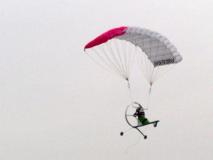

In [7]:
img1 = PIL.Image.open(ll.train.x.items[0])
img1

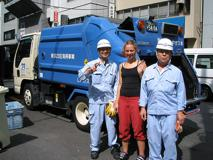

In [8]:
img2 = PIL.Image.open(ll.train.x.items[4000])
img2

/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))


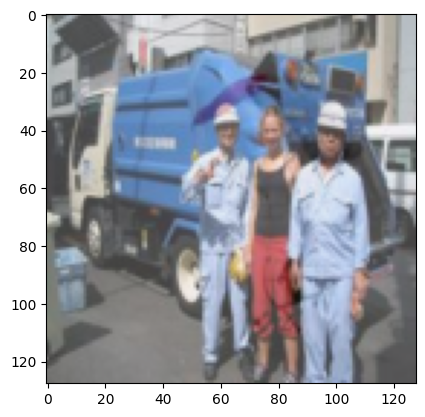

In [9]:
mixed_up = ll.train.x[0] * 0.3 + ll.train.x[4000] * 0.7
plt.imshow(mixed_up.permute(1,2,0));

French horn or tench? The right answer is 70% french horn and 30% tench ;)

## Implementation

The implementation relies on something called the **beta distribution** which in turns uses something which Jeremy still finds mildly terrifying called the **gamma function**.  
To get over his fears, Jeremy reminds himself that **gamma** is just a factorial function that (kinda) interpolates nice and smoothly to non-integers too. How it does that exactly isn't important...

In [10]:
# PyTorch has a log-gamma but not a gamma, so we'll create one
Γ = lambda x: x.lgamma().exp()

If you're not used to typing unicode symbols, on Mac type ctrl-cmd-space to bring up a searchable emoji box. On Linux you can use the compose key. On Windows you can also use a compose key, but you first need to install WinCompose. By default the compose key is the right-hand Alt key.

You can search for symbol names in WinCompose. The greek letters are generally compose-*-letter (where letter is, for instance, a to get greek α alpha).

In [11]:
facts = [math.factorial(i) for i in range(7)]

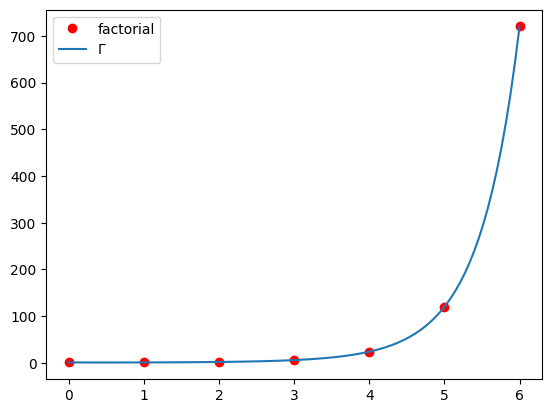

In [12]:
plt.plot(range(7), facts, 'ro')
plt.plot(torch.linspace(0,6, 100), Γ(torch.linspace(0,6, 100)+1))
plt.legend(['factorial','Γ']);

In [13]:
torch.linspace(0,0.9,10)

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000])

In the original article, the authors suggested three things:

1. Create two separate dataloaders and draw a batch from each at every iteration to mix them up
2. Draw a t value following a beta distribution with a parameter α (0.4 is suggested in their article)
3. Mix up the two batches with the same value t.
4. Use one-hot encoded targets

Why the beta distribution with the same parameters α? Well it looks like this:

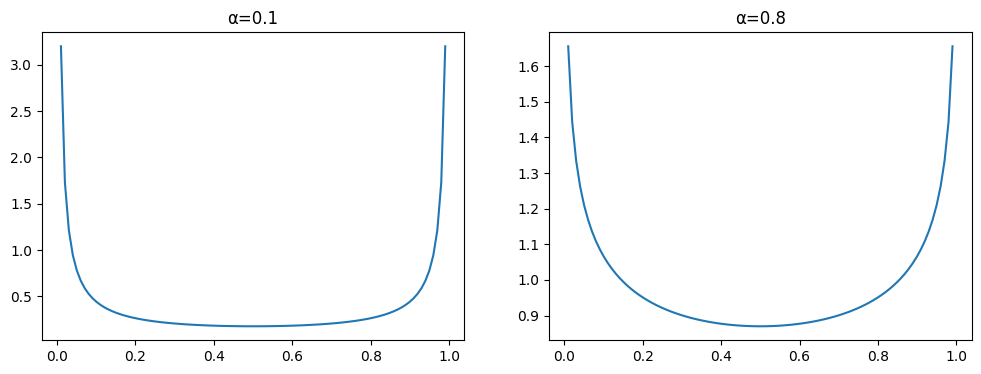

In [14]:
_,axs = plt.subplots(1,2, figsize=(12,4))
x = torch.linspace(0,1, 100)
for α,ax in zip([0.1,0.8], axs):
    α = tensor(α)
#     y = (x.pow(α-1) * (1-x).pow(α-1)) / (gamma_func(α ** 2) / gamma_func(α))
    y = (x**(α-1) * (1-x)**(α-1)) / (Γ(α)**2 / Γ(2*α))
    ax.plot(x,y)
    ax.set_title(f"α={α:.1}")

In [15]:
#export
class NoneReduce():
    def __init__(self, loss_func):
        self.loss_func,self.old_red = loss_func,None

    def __enter__(self):
        if hasattr(self.loss_func, 'reduction'):
            self.old_red = getattr(self.loss_func, 'reduction')
            setattr(self.loss_func, 'reduction', 'none')
            return self.loss_func
        else: return partial(self.loss_func, reduction='none')

    def __exit__(self, type, value, traceback):
        if self.old_red is not None: setattr(self.loss_func, 'reduction', self.old_red)

Then we can use it in MixUp:

In [16]:
#export
from torch.distributions.beta import Beta

def unsqueeze(input, dims):
    for dim in listify(dims): input = torch.unsqueeze(input, dim)
    return input

def reduce_loss(loss, reduction='mean'):
    return loss.mean() if reduction=='mean' else loss.sum() if reduction=='sum' else loss

In [17]:
#export
class MixUp(Callback):
    _order = 90 #Runs after normalization and cuda
    def __init__(self, α:float=0.4): self.distrib = Beta(tensor([α]), tensor([α]))

    def begin_fit(self): self.old_loss_func,self.run.loss_func = self.run.loss_func,self.loss_func

    def begin_batch(self):
        if not self.in_train: return #Only mixup things during training
        λ = self.distrib.sample((self.yb.size(0),)).squeeze().to(self.xb.device)
        λ = torch.stack([λ, 1-λ], 1)
        self.λ = unsqueeze(λ.max(1)[0], (1,2,3))
        shuffle = torch.randperm(self.yb.size(0)).to(self.xb.device)
        xb1,self.yb1 = self.xb[shuffle],self.yb[shuffle]
        self.run.xb = lin_comb(self.xb, xb1, self.λ)

    def after_fit(self): self.run.loss_func = self.old_loss_func

    def loss_func(self, pred, yb):
        if not self.in_train: return self.old_loss_func(pred, yb)
        with NoneReduce(self.old_loss_func) as loss_func:
            loss1 = loss_func(pred, yb)
            loss2 = loss_func(pred, self.yb1)
        loss = lin_comb(loss1, loss2, self.λ)
        return reduce_loss(loss, getattr(self.old_loss_func, 'reduction', 'mean'))

In [18]:
nfs = [32,64,128,256,512]

In [19]:
def get_learner(nfs, data, lr, layer, loss_func=F.cross_entropy,
                cb_funcs=None, opt_func=optim.SGD, **kwargs):
    model = get_cnn_model(data, nfs, layer, **kwargs)
    init_cnn(model)
    return Learner(model, data, loss_func, lr=lr, cb_funcs=cb_funcs, opt_func=opt_func)

In [20]:
cbfs = [partial(AvgStatsCallback,accuracy),
        CudaCallback,
        ProgressCallback,
        partial(BatchTransformXCallback, norm_imagenette),
        MixUp]

In [21]:
learn = get_learner(nfs, data, 0.4, conv_layer, cb_funcs=cbfs)

In [22]:
learn.fit(1)

epoch,train_loss,train_accuracy,valid_loss,valid_accuracy,time


epoch,train_loss,train_accuracy,valid_loss,valid_accuracy,time
0,3.525776,0.199810,2.586946,0.227261,00:17


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Questions: How does softmax interact with all this? Should we jump straight from mixup to inference?

## Label smoothing
Another regularization technique that's often used is label smoothing. It's designed to make the model a little bit less certain of it's decision by changing a little bit its target: instead of wanting to predict 1 for the correct class and 0 for all the others, we ask it to predict `1-ε` for the correct class and `ε` for all the others, with `ε` a (small) positive number and N the number of classes. This can be written as:

$loss = (1-ε) ce(i) + ε \sum ce(j) / N$


where `ce(x)` is cross-entropy of `x` (i.e. -log(px)), and `i` is the correct class. This can be coded in a loss function:

In [23]:
#export
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, ε:float=0.1, reduction='mean'):
        super().__init__()
        self.ε,self.reduction = ε,reduction

    def forward(self, output, target):
        c = output.size()[-1]
        log_preds = F.log_softmax(output, dim=-1)
        loss = reduce_loss(-log_preds.sum(dim=-1), self.reduction)
        nll = F.nll_loss(log_preds, target, reduction=self.reduction)
        return lin_comb(loss/c, nll, self.ε)

Note: we implement the various reduction attributes so that it plays nicely with MixUp after.

In [24]:
cbfs = [partial(AvgStatsCallback,accuracy),
        CudaCallback,
        ProgressCallback,
        partial(BatchTransformXCallback, norm_imagenette)]

In [25]:
learn = get_learner(nfs, data, 0.4, conv_layer, cb_funcs=cbfs, loss_func=LabelSmoothingCrossEntropy())

In [26]:
learn.fit(1)

epoch,train_loss,train_accuracy,valid_loss,valid_accuracy,time


epoch,train_loss,train_accuracy,valid_loss,valid_accuracy,time
0,3.192422,0.253142,2.323062,0.360764,00:15


And we can check our loss function `reduction` attribute hasn't changed outside of the training loop:

In [27]:
assert learn.loss_func.reduction == 'mean'